In [188]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [189]:
df = pd.read_csv('/content/UpdatedResumeDataSet.csv')

In [190]:
df = df.drop_duplicates(subset=['Resume']).reset_index(drop=True)

In [191]:
df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [192]:
df.tail()

,Category,Resume
161,Testing,Computer Skills: â¢ Proficient in MS office (...
162,Testing,â Willingness to accept the challenges. â ...
163,Testing,"PERSONAL SKILLS â¢ Quick learner, â¢ Eagerne..."
164,Testing,COMPUTER SKILLS & SOFTWARE KNOWLEDGE MS-Power ...
165,Testing,Skill Set OS Windows XP/7/8/8.1/10 Database MY...


In [193]:
df.shape

(166, 2)

In [194]:
df.describe()

,Category,Resume
count,166,166
unique,25,166
top,Java Developer,Skills * Programming Languages: Python (pandas...
freq,13,1


In [195]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166 entries, 0 to 165
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  166 non-null    object
 1   Resume    166 non-null    object
dtypes: object(2)
memory usage: 2.7+ KB


In [196]:
df['Category'].value_counts()

,count
Category,
Java Developer,13
Database,11
Advocate,10
HR,10
Data Science,10
Automation Testing,7
DevOps Engineer,7
Testing,7
DotNet Developer,7


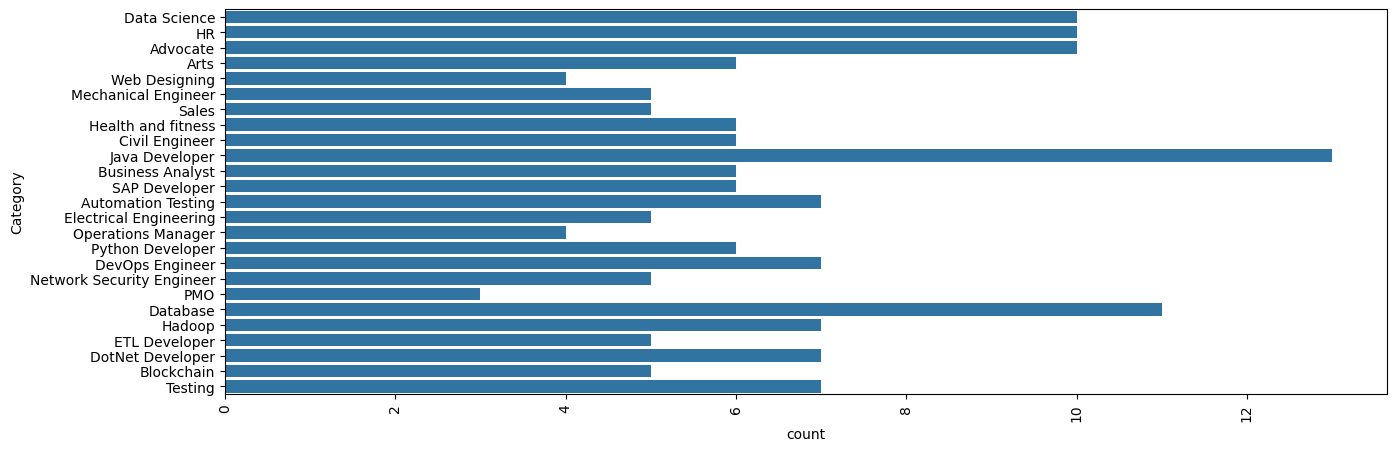

In [197]:
plt.figure(figsize=(15,5))
sns.countplot(df['Category'])
plt.xticks(rotation=90)
plt.show()

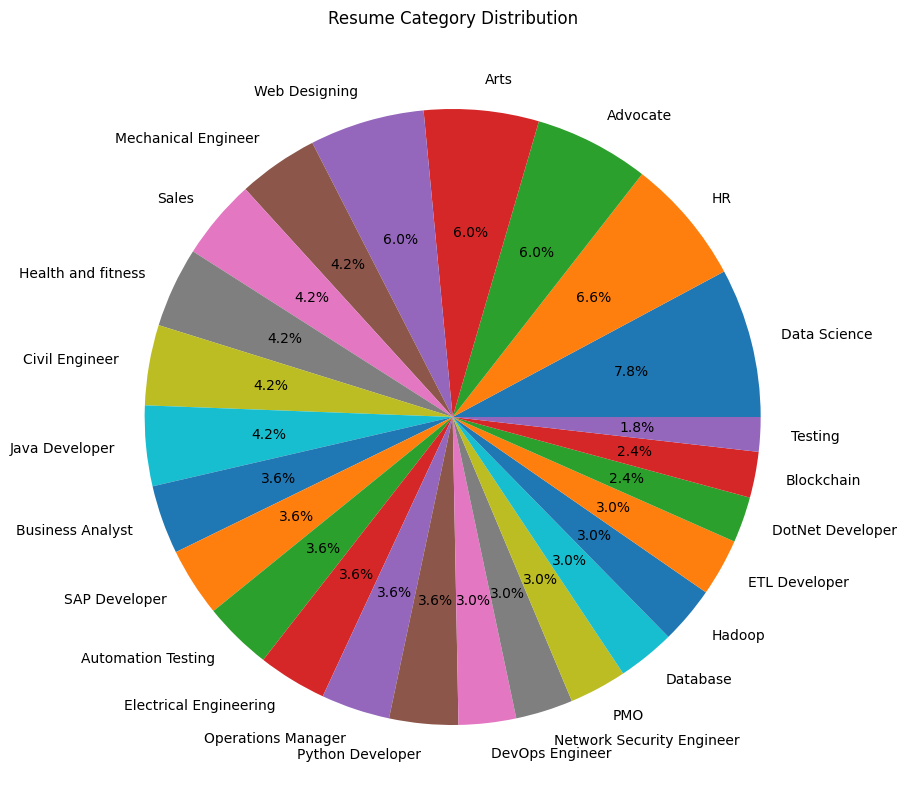

In [198]:
counts = df['Category'].value_counts()
labels = df['Category'].unique()
plt.figure(figsize=(15,10))
plt.pie(counts, labels=labels, autopct='%1.1f%%')
plt.title('Resume Category Distribution')
plt.show()

In [199]:
df['Resume'][0]

'Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask, Git, Docker, computer vision - Open CV and understanding of Deep learning.Education Details \r\n\r\nData Science Assurance Associate \r\n\r\nData Science Assurance Associate - Ernst & Young LLP\r\nSkill Details \r\nJAVASCRIPT- Exprience - 24 months\r\njQuery- Exprience - 24 months\r\nPython- Exprience - 24 monthsCompany Details \r\ncompany - Ernst & Young LLP\r\ndescription - Fraud Investigatio

In [200]:
import re
def cleanresume(txt):
  txt = re.sub(r'http\S+|www\S+', ' ', txt)        # URLs
  txt = re.sub(r'\S+@\S+', ' ', txt)              # Emails
  txt = re.sub(r'#\S+', ' ', txt)                 # Hashtags
  txt = re.sub(r'RT|cc', ' ', txt)                # RT and cc
  txt = re.sub(r'\d+', ' ', txt)                  # Numbers

  txt = re.sub(r'[%s]' % re.escape("""!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~"""),' ',txt)
  txt = re.sub(r'[^\x00-\x7F]+', ' ', txt)        # Non-ASCII chars
  txt = re.sub(r'\s+', ' ', txt)                  # Extra spaces

  return txt.strip()

  return cleantxt

In [201]:
df['Resume'] = df['Resume'].apply(cleanresume)

print(df['Resume'][0])

Skills Programming Languages Python pandas numpy scipy scikit learn matplotlib Sql Java JavaScript JQuery Machine learning Regression SVM Na ve Bayes KNN Random Forest Decision Trees Boosting techniques Cluster Analysis Word Embedding Sentiment Analysis Natural Language processing Dimensionality reduction Topic Modelling LDA NMF PCA Neural Nets Database Visualizations Mysql SqlServer Cassandra Hbase ElasticSearch D js DC js Plotly kibana matplotlib ggplot Tableau Others Regular Expression HTML CSS Angular Logstash Kafka Python Flask Git Docker computer vision Open CV and understanding of Deep learning Education Details Data Science Assurance Associate Data Science Assurance Associate Ernst Young LLP Skill Details JAVASCRIPT Exprience months jQuery Exprience months Python Exprience monthsCompany Details company Ernst Young LLP description Fraud Investigations and Dispute Services Assurance TECHNOLOGY ASSISTED REVIEW TAR Technology Assisted Review assists in a elerating the review proces

In [202]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Category'] = le.fit_transform(df['Category'])

In [203]:
df['Category'].unique()

array([ 6, 12,  0,  1, 24, 16, 22, 14,  5, 15,  4, 21,  2, 11, 18, 20,  8,
       17, 19,  7, 13, 10,  9,  3, 23])

In [204]:
Tfidf = TfidfVectorizer(stop_words='english', ngram_range=(1, 2), max_features=5000, sublinear_tf=True)

Tfidf.fit(df['Resume'])
required_txt = Tfidf.transform(df['Resume'])

In [205]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(required_txt, df['Category'], test_size=0.2, random_state=42,  stratify=df['Category'])

In [206]:
x_train.shape

(132, 5000)

In [207]:
x_test.shape

(34, 5000)

In [208]:
from sklearn.svm import LinearSVC
svm = LinearSVC(class_weight='balanced', C=1.0, max_iter=3000, dual=False)
svm.fit(x_train, y_train)




LinearSVC(class_weight='balanced', dual=False, max_iter=3000)

In [209]:
y_pred = svm.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"\n{'='*50}")
print(f"SVM Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"{'='*50}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))




SVM Accuracy: 0.9118 (91.2%)

Classification Report:
                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         2
                     Arts       1.00      1.00      1.00         1
       Automation Testing       0.50      1.00      0.67         1
               Blockchain       1.00      1.00      1.00         1
         Business Analyst       1.00      1.00      1.00         1
           Civil Engineer       1.00      1.00      1.00         1
             Data Science       1.00      1.00      1.00         2
                 Database       1.00      1.00      1.00         2
          DevOps Engineer       1.00      1.00      1.00         1
         DotNet Developer       1.00      1.00      1.00         2
            ETL Developer       1.00      1.00      1.00         1
   Electrical Engineering       1.00      1.00      1.00         1
                       HR       1.00      1.00      1.00         2
       

In [210]:
print(y_pred)

[ 7 18  3  8  5 17 19 21 12 18 14 10  9  0  9  6 13 15  2 15  4  2  6 12
  7 23 20  0 22 15 15 13  1 11]


In [211]:
import pickle
pickle.dump(Tfidf, open('Tfidf.pkl', 'wb'))
pickle.dump(svm, open('svm.pkl', 'wb'))           # Changed filename
pickle.dump(le, open('label_encoder.pkl', 'wb'))

In [212]:
myresume = """


SUMMARY
Data scientist and researcher with 7.5 + years of experience and a Total of 10 + years of experience in wide functions, including Predictive modelling, MLOps, Data Pre-processing, Feature engineering, Machine learning, Deep learning, Computer Vision, Natural Language Processing, Audio Processing, Satellite Image Processing, Quantum Computing, Quantum Machine learning, Enterprise LLMs Services.
EDUCATION
demo Technological University
M.E (Computer Engineering)                                                                                            2013-2015
demo University
B.E (Information Technology)                                                                                           2007-2011
EXPERIENCE
Sr.AWS AI ML Solution Architect (Chief Data Scientist)                                    2022(May)-Current
Design and/or deliver solutions, assets, and content with MLOps Architecture Design.
Apply methodology and governance around project development.
Document and articulate a clear understanding of customer/partner success criteria.
Apply critical thinking, technical knowledge, and customer/partner insights to solve problems with industry methodologies and frameworks.
Collaborate with IBM and AWS specialists to design and build complex enterprise solutions with the foundation of Red Hat Open Shift, AWS Infrastructure, and IBM Software technology.
Standardize solutions in accordance with the AWS Well-Architected Framework across all pillars, including operational excellence, security, performance efficiency, cost optimization, and reliability.
Define, lead, and execute architecture design workshops and white-boarding sessions to build implementation plans.
Develop deep relationships with key customers through solution integration to drive long-term IBM and AWS adoption.
Team well with our critical IBM & Red Hat business units and strategic partners to support our partnership.
Consult as a subject matter expert on our IBM/AWS technology and services portfolio.
Author use cases, reference architectures, blog posts, and other field and external content.
Work in sandbox environments to demonstrate IBM Hybrid Cloud Capabilities with AWS.
Work with IBM Research on Cross-functional Research concepts on all AI technology.

Enterprise LLMs Services: Amazon Bedrock, Amazon Titan, IBM WatsonX.ai, Azure OpenAI, NvidiaNemo, Google PaLM
Cygnet Infotech Pvt. Ltd
Sr. Data Scientist & AI Consultant                                                         	               2020(Apr)-Current
Interact with customers, develop use-cases on ML/AI, and use the same in solution integration on existing business.
Selecting features, building, and optimizing classifiers using machine learning techniques
Data mining using state-of-the-art methods and Handling large-scale data using ETL: processing tools such as Pyspark and Data Bricks.
Extending company's data with third party sources of information when needed
Enhancing data collection procedures to include information that is relevant for building analytic systems
Processing, cleansing, and verifying the integrity of data used for analysis
Doing ad-hoc analysis and presenting results in a transparent manner
Creating automated anomaly detection systems and constant tracking of its performance
Research and devise innovative statistical models for data analysis
Work as the lead data strategist, identifying and integrating new datasets that can be leveraged through our product capabilities and work closely with the engineering team to strategize and execute the development of data products.
Collaborate with product design and engineering to develop an understanding of needs and Quality.
Analyze data for trends and patterns and Interpret data with a clear objective in mind.
Provide deep learning and machine learning-based solutions to Solve various Real-world problems.
Projects: Recommendation System, Chatbot Architecture Designing, Image Classification based project

Sr. Data Scientist                                                                                       	2019(Sep)-2020(Feb)
Research and devise innovative statistical models for data analysis.
Work as the lead data strategist, identifying and integrating new datasets that can be leveraged through our product capabilities and work closely with the engineering team to strategize and execute the development of data products.
Collaborate with product design and engineering to develop an understanding of needs and Quality.
Formulating, suggesting, and managing data-driven projects which are geared at furthering the business's interests.
Analyse data for trends and patterns and Interpret data with a clear objective in mind.
Cross-validating models to ensure their generalizability.
Keep current with technical and industry developments in dairy sector.
Execute analytical experiments methodically to help solve various problems and make a true impact across dairy domains industries.
Monitoring the performance of Junior Data Scientists and providing them with practical guidance, as needed.
Selecting and Employing advance deep learning and machine-learning based solutions to Solve varies Real world problem.
Projects: Milk Adulteration, Calf Behaviour Analysis, Calf health prediction, Animal Lameness detection etc.
Softweb Solutions (Avnet Company Fortune 500
Data Scientist                                                                                       	           2018(Jan)-2019(Sep)
Hands-on experience in selecting features, building, and optimizing classifiers using machine-learning techniques.
Enhancing data collection procedures to include information that is relevant for building analytic systems
Processing, cleansing, and verifying the integrity of data used for analysis.
Doing ad-hoc analysis and presenting results in a clear manner.
Creating anomaly detection systems and constant tracking of its performance.
Having strong knowledge in Statistics, Feature Engineering, Model Selection, Model
Evaluation, and Feature Scaling to build accurate machine learning.
Experience in tuning and optimize ML/DL model for performance improvement.
Hands on  experience working  with live  projects  on  different  machine  learning techniques.
Having strong problem-solving capabilities.
Working with most demand industrial technology Framework like pandas, NumPy, matplotlib, nltk(NLP), keras(Deep Learning, tensor flow scikit learn(Machine learning), opencv etc.
Projects: Image  Classifications,  Facial  Expression  Recognitions,  Recommendation  system, Predictive Modelling, Regression Analysis
Solaris Publication
Jr. Data Scientist                                                                                            2017(Jan)-2018(Jan)
Requirement gathering from the Business Team.
Increased training data using the Image augmentation technique.
Used Transfer learning concept to achieve reasonable accuracy.
Implemented Deep learning image classification model.
Validated Model on thousands of images.
Projects: Image Classification, Seasonality Trends Analysis, Recommendation System
Silver oak College of Engineering and Technology
Researcher and Assistant Professor                                                                      2015(Dec)-2016(Dec)
Teaching a student Academic Syllabus with practical labs.
Guide students on their master thesis on Data Mining and Deep learning.
Initiated to work with Student on the new research project with new technology.
Guide a student to their Academic project.

L.D College of Engineering
Lecturer					                                                      2015(May)- 2015(Dec)
Mantrasoft India	              					     Ahmedabad, Gujarat
PHP developer					                                         2011(Aug)- 2013(Aug)
TECHNICAL SKILLS
Programming Languages: Python, R
Databases: PostgreSQL, Redshift, MongoDB
MLOps Framework: MLFlow, Kubeflow, DVC, Docker, Kubernetes, OpenShift, Amazon SageMaker, EKS, ECS, ECR, GitLFS, SageMaker Features tore
Big Data Frameworks:  Hadoop streaming, DataBricks, Kafka
Libraries: pandas, NumPy, Sklearn, SciPy, Keras, nltk, spacy, matplotlib, pyserial, TensorFlow, Pytorch, pyspark
Machine Learning: Regression, Random Forest, boosted decision trees, naive Bayes, SVM, k- means clustering, SVD/PCA, Anomaly Detection, Deep Learning algorithms, Time Series Analysis, Sequence2Sequence learning, Meta-learning
Deep learning: NN, RNN, LSTM, GRU, CNN, Transfer Learning, Optimization of Algorithm, Regularization, Hyperparameter Tuning, Batch Normalization
Object Detection Algorithm:  YOLOv5, SSD, RetinaNet, R-CNN, Faster R-CNN, Efficient Det
Semantic Segmentation Algorithms: Unet, FCN, SegNet, DeepLab, DeepLabv3 Unet++
Generative Adversarial Networks: GAN, Style GAN, DC GAN, SRGAN, ESRGAN
Instance Segmentation: Mask R-CNN, CenterMask
Vision Transformer, Autoencoder, Capsule Net, RBF, Deep Belief Network, Variance Auto Encoder, Wavelet CNN, etc.
Natural Language Processing: Encoder-Decoder Model (BERT, ALBERT, etc.), NER, Language Modelling, etc.
Frameworks: NLTK, Spacy, Gensim, Transformers, torchtext etc.
Statistics: Descriptive Statistics, Inference Statistics, Bayesian Inference
Enterprise LLMs Services Expertise: Amazon Bedrock, Amazon Titan, IBM WatsonX.ai, Azure OpenAI, NvidiaNemo, Google PaLM
LLMs Knowledge: LLaMa2, GPT-4, Claude, ChatGPT, OpenChat, UltraLM, OpenCoderPlus, WizardLM, Nous Hermes, Vicuna, Baize-v2, Guanaco, Minotaur, Davinci003, Falcon, Alpaca Farm PPO Sim (GPT-4), Pythia, Cohere, Alpaca Farm PPO Human, Cohere Chat, Alpaca, Falcon 7B Instruct, Davinci001.

ACHIEVEMENT
Technical Book Reviewer with Manning Publication, Packt Publication, and Apress Publications, BPB publication.
Achieved Star Club Member of GitHub contains more than 14k+ stars and 5.3k+ Github followers.
Certified Quantum Computing Practitioner from Qubit by Qubit (The coding school) MIT and Oxford University join Program.
IBM Certified Quantum Computing and Quantum Machine learning Practitioner.
Published more than 20+ Research papers with Publications such as IEEE, Taylor Frances, Springer, etc.
Book Author of Hands-on Time Series Analytics with Python - Book
Coursera Certified Specialization in Tensorflow in Practice, Deep learning AI, Advance Data Science with IBM
	Link: https://www.linkedin.com/in/ashishpatel2604/
Three-time potential  Kernel  Winner  on World’s best  data  science  platform Kaggle(Google Data Science Platform)

PERSONAL
Citizenship: demo
Natural Languages:  English,
Interests: traveling, photography, distance running, choir, fantasy baseball
$0 """

In [213]:
import pickle
svm_loaded = pickle.load(open('svm.pkl', 'rb'))
Tfidf_loaded = pickle.load(open('Tfidf.pkl', 'rb'))
le_loaded = pickle.load(open('label_encoder.pkl', 'rb'))


In [214]:
cleaned_resume = cleanresume(myresume)
input_features = Tfidf_loaded.transform([cleaned_resume])

In [215]:
prediction = svm_loaded.predict(input_features)
predicted_category = le_loaded.inverse_transform(prediction)

print(f"\nPredicted Category: {predicted_category[0]}")


Predicted Category: Data Science
